In [1]:
f_switch: float = 6.78e6
delay_deg: float = 47

# LCCL-S 보상 토폴로지 설계 (6.78 MHz)

추출된 등가회로(코일 Z-행렬, `COIL.csv`)를 사용해 LCCL-S 보상망 소자값을 설계.

**입력**: 풀브릿지 ±320 V 사각파 → 기본파 RMS `Vin = (2√2/π)·320 = 288 V`  
**부하**: 최대효율 AC 등가부하 `R_L,opt` (뒤단 정류+DC-DC가 실제 500 W 부하를 이 값으로 환산 매칭)  
**목표**: 500 W 전달, ZVS 위해 입력전류 25° 지연(∠Zin=+25°)

### 공진점 3개와 튜닝 배치
| 공진 | 소자 | 동조 |
|---|---|---|
| ① LC (앞단) | `Lf` ↔ `Cf` | **25° 디튠** (Cf를 동조값보다 줄여 입력을 유도성으로) |
| ② CL (Tx 직렬) | `C1` ↔ `(L1−Lf)` | 6.78 MHz 정확 |
| ③ S (Rx 직렬) | `C2` ↔ `L2` | 6.78 MHz 정확 |

자유도: **Lf**(코일전류=전력 레벨) + **Cf 디튠량**(25°). `C1,C2`는 종속.  
보상 캡은 단자 리액턴스 `Im(Z)` 기준으로 잡아 코일 자기용량을 자동 반영.

## 1. 파라미터 — 첫 셀의 `f_switch`, `delay_deg` 사용 + 코일 Z행렬 로드

In [2]:
import csv, math, cmath
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

f0  = f_switch                 # 동작 주파수 [Hz]  (첫 셀)
w   = 2*math.pi*f0
phi_tgt = delay_deg            # ZVS 입력위상 목표 [deg] (첫 셀)
Vdc = 320.0
Vin = 2*math.sqrt(2)/math.pi*Vdc      # 풀브릿지 사각파 기본파 RMS
P_tgt = 500.0                  # 목표 부하전력 [W]

# --- 6.78 MHz 정밀 코일 Z행렬 (COIL.csv) ---
h, d = (lambda r:(r[0],r[1]))(list(csv.reader(open('COIL.csv'))))
def Zc(re,im): return float(d[h.index(re)])+1j*float(d[h.index(im)])
Z11 = Zc('re(Zt(1_T1,1_T1)) []','im(Zt(1_T1,1_T1)) []')   # Tx
Z22 = Zc('re(Zt(2_T1,2_T1)) []','im(Zt(2_T1,2_T1)) []')   # Rx
Z21 = Zc('re(Zt(2_T1,1_T1)) []','im(Zt(2_T1,1_T1)) []')   # 상호
Z12 = Z21                                                  # 상반성
R1, R2, wM = Z11.real, Z22.real, Z21.imag
print(f'Vin={Vin:.1f} V (기본파)   f0={f0/1e6:.2f} MHz   목표위상={phi_tgt}°')
print(f'Z11={Z11.real:.4f}{Z11.imag:+.2f}j   Z22={Z22.real:.4f}{Z22.imag:+.2f}j   ω0M={wM:.3f}Ω')

Vin=288.1 V (기본파)   f0=6.78 MHz   목표위상=47°
Z11=0.0936+100.62j   Z22=0.0574+106.90j   ω0M=2.057Ω


## 2. 최적 부하 & 유효 인덕턴스

최대효율 부하 `R_L,opt = R2·√(1 + (ω0M)²/(R1R2))`. 유효 L은 단자 리액턴스에서: `L_eff = Im(Z)/ω`.

In [3]:
FoM  = wM**2/(R1*R2)                    # 품질지수 k²Q1Q2
RL   = R2*math.sqrt(1+FoM)              # 최대효율 AC 부하
eta_max = FoM/(1+math.sqrt(1+FoM))**2
L1e  = Z11.imag/w                       # Tx 유효 L (자기용량 포함)
L2e  = Z22.imag/w                       # Rx 유효 L
C2   = 1/(w**2*L2e)                     # ③ Rx S: L2 완전 상쇄
print(f'품질지수 kᵤ²={FoM:.0f}  →  링크 최대효율 η_max={eta_max*100:.1f}%')
print(f'최대효율 부하 R_L,opt = {RL:.3f} Ω')
print(f'L1_eff={L1e*1e6:.4f} µH   L2_eff={L2e*1e6:.4f} µH   →  C2={C2*1e12:.2f} pF')

품질지수 kᵤ²=787  →  링크 최대효율 η_max=93.1%
최대효율 부하 R_L,opt = 1.613 Ω
L1_eff=2.3620 µH   L2_eff=2.5093 µH   →  C2=219.60 pF


## 3. 회로 해석기 (6.78 MHz Z행렬 정확해)

코일을 측정 Z행렬로 두고 보상망을 연결해 노드해석. `solve(Lf,Cf)` → 모든 전류·전력·입력위상 반환.  
`C1`은 Lf에 종속(② CL 동조), `Cf`는 디튠 자유변수, `C2`는 고정.

In [4]:
def solve(Lf, Cf):
    C1 = 1/(w**2*(L1e-Lf))                  # ② Tx CL: (L1-Lf) 동조
    D2 = Z22 + 1/(1j*w*C2) + RL             # Rx 루프 임피던스
    Zt = Z11 - Z12*Z21/D2 + 1/(1j*w*C1)     # P노드에서 본 코일가지
    V_P  = Vin/(1 + 1j*w*Lf*(1/Zt + 1j*w*Cf))
    I1   = V_P/Zt                           # Tx 코일전류
    I2   = -Z21*I1/D2                        # Rx 코일전류
    I_in = V_P*(1/Zt + 1j*w*Cf)             # 인버터 출력전류
    Pout = abs(I2)**2*RL
    Pin  = (Vin*I_in.conjugate()).real
    Zin  = Vin/I_in
    return dict(C1=C1, I1=I1, I2=I2, I_in=I_in, V_P=V_P, Pout=Pout,
                Pin=Pin, Zin=Zin, phase=math.degrees(cmath.phase(Zin)), eta=Pout/Pin)

## 4. 해 찾기 — [∠Zin = 25°, P_out = 500 W]

미지수 `Lf`(전력 레벨), `Cf`(25° 디튠) 두 개를 두 조건에 맞춰 동시 해.

In [5]:
def resid(x):
    r = solve(x[0], x[1])
    return [r['phase']-phi_tgt, r['Pout']-P_tgt]

Lf0 = Vin/(w*15.0); Cf0 = 1/(w**2*Lf0)      # 초기값 (코일~15A 가정)
Lf, Cf = fsolve(resid, [Lf0, Cf0])
r = solve(Lf, Cf)
C1 = r['C1']; Cf_tuned = 1/(w**2*Lf)
print(f'수렴: ∠Zin={r["phase"]:.2f}°  Pout={r["Pout"]:.1f}W')

수렴: ∠Zin=47.00°  Pout=500.0W


## 5. 설계 결과

In [6]:
print('=== LCCL-S 소자값 @ {:.2f} MHz ==='.format(f0/1e6))
print(f'Lf = {Lf*1e6:.4f} µH      (앞단 인덕터, 전류 손잡이)')
print(f'Cf = {Cf*1e12:.2f} pF      (동조 {Cf_tuned*1e12:.1f}pF 대비 {(Cf/Cf_tuned-1)*100:+.1f}% 디튠 → 25° ZVS)')
print(f'C1 = {C1*1e12:.2f} pF      (Tx 직렬, (L1-Lf) 동조)')
print(f'C2 = {C2*1e12:.2f} pF      (Rx 직렬 S, L2 동조)')
print(f'R_L= {RL:.3f} Ω        (AC 등가부하)')
print()
print('=== 동작점 검증 ===')
print(f'입력위상  ∠Zin = {r["phase"]:.2f}°   (ZVS 목표 {phi_tgt}°)')
print(f'부하전력  Pout = {r["Pout"]:.1f} W    입력 Pin = {r["Pin"]:.1f} W    효율 η = {r["eta"]*100:.1f}%')
print(f'인버터전류 |I_in| = {abs(r["I_in"]):.2f} A   (한계 9A, 여유 {9/abs(r["I_in"]):.1f}배)')
print(f'Tx 코일전류 |I_L1| = {abs(r["I1"]):.1f} A')
print(f'Rx 코일전류 |I_L2| = {abs(r["I2"]):.1f} A   <-- 코일/litz 전류정격 확인 필요')
print(f'입력 임피던스 |Zin| = {abs(r["Zin"]):.1f} Ω')

=== LCCL-S 소자값 @ 6.78 MHz ===
Lf = 0.4142 µH      (앞단 인덕터, 전류 손잡이)
Cf = 1141.28 pF      (동조 1330.3pF 대비 -14.2% 디튠 → 25° ZVS)
C1 = 282.91 pF      (Tx 직렬, (L1-Lf) 동조)
C2 = 219.60 pF      (Rx 직렬 S, L2 동조)
R_L= 1.613 Ω        (AC 등가부하)

=== 동작점 검증 ===
입력위상  ∠Zin = 47.00°   (ZVS 목표 47°)
부하전력  Pout = 500.0 W    입력 Pin = 536.9 W    효율 η = 93.1%
인버터전류 |I_in| = 2.73 A   (한계 9A, 여유 3.3배)
Tx 코일전류 |I_L1| = 14.3 A
Rx 코일전류 |I_L2| = 17.6 A   <-- 코일/litz 전류정격 확인 필요
입력 임피던스 |Zin| = 105.4 Ω


## 6. 주파수 응답 — ZVS 위상 확인

동작점 부근에서 입력 위상이 +25°(유도성)인지, 전 대역 거동 확인. 코일은 6.78MHz Z값으로 고정한 근사이므로 ±10% 부근만 유효.

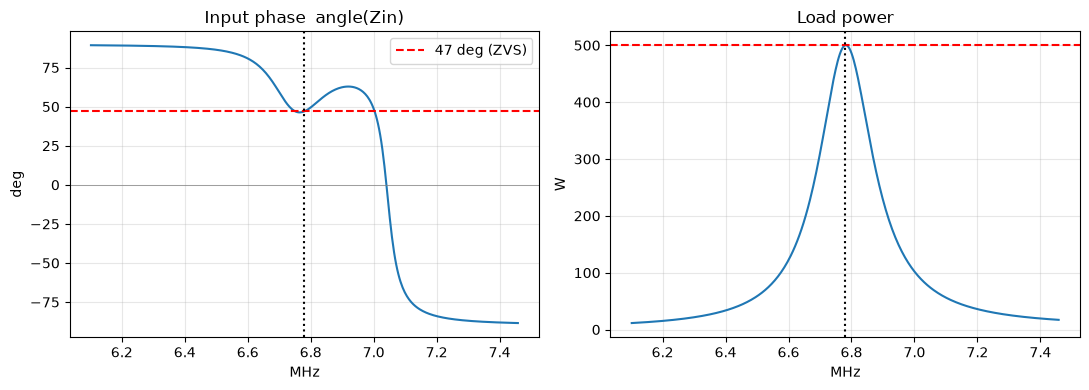

In [7]:
fr = np.linspace(0.90, 1.10, 401)*f0
ph=[]; po=[]
for fx in fr:
    ww=2*math.pi*fx
    # 동작점 근방: 코일 Z는 6.78MHz값 고정(국소 근사), 보상소자는 주파수 따라 변함
    C1l=C1; C2l=C2
    D2=Z22+1/(1j*ww*C2l)+RL
    Zt=Z11-Z12*Z21/D2+1/(1j*ww*C1l)
    V_P=Vin/(1+1j*ww*Lf*(1/Zt+1j*ww*Cf))
    I1=V_P/Zt; I2=-Z21*I1/D2; I_in=V_P*(1/Zt+1j*ww*Cf)
    ph.append(math.degrees(cmath.phase(Vin/I_in))); po.append(abs(I2)**2*RL)
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(fr/1e6,ph); ax[0].axhline(phi_tgt,color='r',ls='--',label=f'{phi_tgt} deg (ZVS)')
ax[0].axvline(f0/1e6,color='k',ls=':'); ax[0].axhline(0,color='gray',lw=.5)
ax[0].set_title('Input phase  angle(Zin)'); ax[0].set_xlabel('MHz'); ax[0].set_ylabel('deg'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(fr/1e6,po); ax[1].axhline(P_tgt,color='r',ls='--'); ax[1].axvline(f0/1e6,color='k',ls=':')
ax[1].set_title('Load power'); ax[1].set_xlabel('MHz'); ax[1].set_ylabel('W'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. LTspice 넷리스트

인버터=AC 전압원(기본파 등가). 코일은 추출 등가회로(`(L+R1)//C//R2` + 결합 K)로 치환하거나, 여기선 단순화해 `L+R`로 표기.

In [8]:
net = f'''* LCCL-S @ {f0/1e6:.2f} MHz  (Vin={Vin:.0f}Vrms fund, RL={RL:.2f}ohm)
Vin S 0 SINE(0 {Vin*math.sqrt(2):.1f} {f0:.0f})
Lf  S  P  {Lf:.4g}
Cf  P  0  {Cf:.4g}
C1  P  T1 {C1:.4g}
* --- Tx coil ---  (Im(Z11) 유효: L1e={L1e*1e6:.3f}uH, R1={R1:.4g})
Rtx T1 Tm {R1:.4g}
Ltx Tm 0  {L1e:.4g}
* --- Rx coil ---  (Im(Z22) 유효: L2e={L2e*1e6:.3f}uH, R2={R2:.4g})
Lrx R1n 0 {L2e:.4g}
Rrx R1n R1a {R2:.4g}
C2  R1a R2n {C2:.4g}
RL  R2n 0  {RL:.4g}
K1  Ltx Lrx {wM/(w*math.sqrt(L1e*L2e)):.4f}
.ac lin 401 {0.9*f0:.0f} {1.1*f0:.0f}
.end'''
print(net)
open('LCCL_S_6p78MHz.cir','w').write(net)
print('\n-> LCCL_S_6p78MHz.cir 저장')

* LCCL-S @ 6.78 MHz  (Vin=288Vrms fund, RL=1.61ohm)
Vin S 0 SINE(0 407.4 6780000)
Lf  S  P  4.142e-07
Cf  P  0  1.141e-09
C1  P  T1 2.829e-10
* --- Tx coil ---  (Im(Z11) 유효: L1e=2.362uH, R1=0.09362)
Rtx T1 Tm 0.09362
Ltx Tm 0  2.362e-06
* --- Rx coil ---  (Im(Z22) 유효: L2e=2.509uH, R2=0.05745)
Lrx R1n 0 2.509e-06
Rrx R1n R1a 0.05745
C2  R1a R2n 2.196e-10
RL  R2n 0  1.613
K1  Ltx Lrx 0.0198
.ac lin 401 6102000 7458000
.end

-> LCCL_S_6p78MHz.cir 저장
